In [53]:
#Standard operational package imports
import numpy as np
import pandas as pd

#Important import for modeling and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#To create synthetic data
from sklearn.datasets import make_blobs

#Visulization pakage import
import seaborn as sns

In [54]:
#To focus on modeling and analysis, use synthetic data over here

rng= np.random.default_rng(seed=44)

#To create reproducible synthetic data, use it to generate cluster data
#At this moment, dk the cluster number will be generated 

In [55]:
#Using a random number generator and assigning the results to a variable, can avoid knowing the number of clusters of the data having
#So able to use Inertia and Silhouette coe to determine it 

#Create synthetic data w/unknown of clusters
centers= rng.integers(low=3, high=7)
X, y, z= make_blobs(n_samples= 1000, n_features= 6, centers= centers, return_centers= True, random_state= 42)
#^to use make_blobs and random number generator to create data that has an unknown number of clusters

In [56]:
#Create Pandas Df from the data
X= pd.DataFrame(X)
X.head()

#Currently hv 6 features, = too much dimension to visualize in 2D/3D, and cant oberve how many cluster there are 

,0,1,2,3,4,5
0,-1.534288,5.467808,-6.945988,1.403934,1.553836,-7.618236
1,-6.681020,6.717808,2.764396,4.460744,-8.286569,10.959708
2,-8.678310,7.825306,3.139699,5.609951,-9.948079,8.072149
3,-6.667385,7.147637,2.145505,4.712937,-9.544708,11.093248
4,-2.753835,-4.209968,0.620345,-7.439505,-4.405723,-2.046149


In [57]:
#K-Means use distances between observation and its measure of similarity, so it is required to scale the numerical data before modeling if it's not already scaled
#Use sklearn.preprocessing import StandardScaler 

In [58]:
#Scale the data 
X_scaled= StandardScaler().fit_transform(X)
X_scaled[:2,:]

array([[-0.03173691,  0.4864719 , -1.32178135,  0.59808997,  1.5703227 ,
        -0.88951855],
       [-1.05006137,  0.68381835,  0.74465777,  1.2564266 , -0.97057774,
         1.92995522]])

In [59]:
#Start modeling after the data is scaled
#Currently hv no idea of the number of clusters, so begin with examining the inertia value of K, it is an arbitrary number of 3

#Instantiate the model
kmeans3= KMeans(n_clusters= 3, random_state=42)

In [60]:
#Fit the model to the data
kmeans3.fit(X_scaled)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [61]:
print('Clusters:', kmeans3.labels_ )
print('Inertia:', kmeans3.inertia_ )

#Since K-Means cluster in 3, so the value return will be from 0-2
#Inertia returns the sum of squared distances from each sample to its closest cluster center

Clusters: [2 0 0 0 1 1 1 0 0 2 1 0 0 2 0 0 0 0 1 1 1 0 0 0 2 2 1 0 0 1 1 0 1 1 2 2 1
 0 0 0 1 0 1 0 0 1 1 2 0 2 1 1 1 2 2 2 1 0 1 2 1 1 1 1 1 1 1 2 1 1 0 1 1 1
 0 1 0 2 2 0 2 0 1 2 1 0 2 2 0 2 0 1 2 0 1 2 1 0 0 1 1 0 0 0 0 0 0 1 1 0 2
 1 0 1 0 0 1 1 2 1 1 1 0 1 1 0 0 1 2 0 2 2 2 1 0 2 2 1 0 1 1 1 0 2 2 2 1 1
 0 1 1 0 1 1 0 0 2 0 2 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 2 0 0 2 2 1 0 1 0 1
 0 2 0 2 0 1 1 1 0 0 0 2 2 0 1 0 0 1 0 1 1 1 1 1 2 1 2 0 0 1 2 2 0 1 1 2 1
 0 0 0 0 1 1 1 0 2 1 2 0 2 0 2 1 1 0 0 0 2 2 1 1 2 2 2 0 0 0 1 1 1 0 0 0 1
 0 1 2 1 0 0 2 2 1 1 0 1 2 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 1 1 0 2 1 0 1 2 2
 1 0 0 1 0 0 0 0 0 0 2 0 2 1 0 0 2 1 1 0 1 0 0 2 0 1 0 0 0 1 1 1 2 2 2 1 2
 2 2 0 0 2 0 2 1 0 1 2 0 2 1 0 1 0 0 0 0 1 1 0 1 0 1 1 1 2 0 0 0 0 0 1 1 2
 1 0 0 1 0 1 1 0 1 0 2 0 0 1 0 1 1 2 0 1 1 1 2 1 1 0 1 0 1 0 2 0 1 0 0 1 1
 2 0 1 1 2 1 1 0 0 0 0 1 0 1 0 0 2 2 1 2 1 1 1 0 0 2 1 0 0 0 1 0 1 0 2 0 1
 2 1 1 1 0 1 2 0 1 2 0 0 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 2 1 2 0 1 1 1 1 2 0
 0 1 0 0 2 2 0 

In [72]:
#Compare the inertia of multiple K value
#Create a list from 2- 1o
num_clusters= [i for i in range(2, 11)]

#Create a function to fit the K means for multiple values of K
#This function calculates the inertia of each K value and will append it into a list

def kmeans_inertia(num_clusters, x_vals):
    '''
    Accepts as arguments list of ints and data array.
    It fits a KMeans model where K= each value in the list of ints
    Return each K-Value's inertia, which is appended to a list.
    '''
    inertia = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        inertia.append(kms.inertia_)

    return inertia

In [76]:
# Calculate inertia for k=2-10
inertia = kmeans_inertia(num_clusters, X_scaled)
inertia

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

[3686.2501587327993,
 1748.1488703079513,
 1124.636893573839,
 239.6543475871843,
 232.7287150801513,
 224.29675072289987,
 216.22784318026913,
 210.9898998155357,
 202.30181069359654]

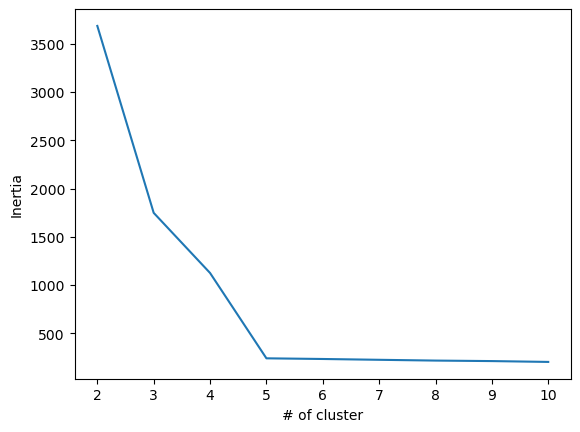

In [78]:
plot= sns.lineplot(x= num_clusters, y=inertia)
plot.set_xlabel('# of cluster');
plot.set_ylabel('Inertia');

In [84]:
#Using Silhouette scores
#Call the function and pass the required parameters= the training data and assigned labels 
kmeans3_sil_score= silhouette_score(X_scaled, kmeans3.labels_)
kmeans3_sil_score

#But only one data returned, so required to compare with other K values from 2- 10 

0.5815196371994132

In [92]:
def kmeans_sil(num_clusters, x_vals): #num_clusters already assigned this var previously 
    '''
    Fits a KMeans model for different values of k.
    Calculates a silhouette score for each k value

    Args:
        num_clusters: (list of ints)  - The different k values to try
        x_vals:       (array)         - The training data

    Returns: 
        sil_score:    (list)          - A list of silhouette scores, one for each \
                                      value of k
    '''
  
    sil_score = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        sil_score.append(silhouette_score(x_vals, kms.labels_))
    
    return sil_score

In [94]:
# Calculate silhouette scores for k=2-10
sil_score = kmeans_sil(num_clusters, X_scaled)
sil_score

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

[0.42005966017510427,
 0.5815196371994132,
 0.649060841277744,
 0.7670656870960784,
 0.6376325996351013,
 0.5100290191946069,
 0.4024771015104519,
 0.3998551090636554,
 0.2748795855657769]

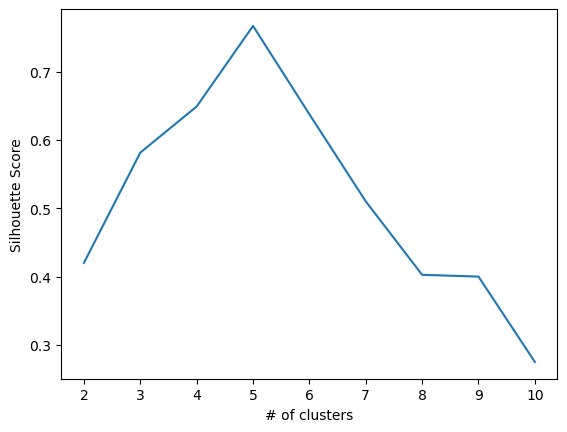

In [90]:
# Create a line plot of silhouette scores 
plot = sns.lineplot(x=num_clusters, y=sil_score)
plot.set_xlabel("# of clusters");
plot.set_ylabel("Silhouette Score");

In [96]:
# Verify our findings (only possible when "correct" number of clusters exists)
centers

5

In [100]:
#Fit a 5-Cluster model to the data
kmeans5= KMeans(n_clusters=5, random_state= 42)
kmeans5.fit(X_scaled)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


KMeans(n_clusters=5, random_state=42)

In [102]:
print(kmeans5.labels_[:5])
print('Unique labels:', np.unique(kmeans5.labels_))

[2 4 4 4 1]
Unique labels: [0 1 2 3 4]


In [104]:
#Create new col that indicates cluster assignment in original Df
X['cluster']= kmeans5.labels_
X.head()

,0,1,2,3,4,5,cluster
0,-1.534288,5.467808,-6.945988,1.403934,1.553836,-7.618236,2
1,-6.681020,6.717808,2.764396,4.460744,-8.286569,10.959708,4
2,-8.678310,7.825306,3.139699,5.609951,-9.948079,8.072149,4
3,-6.667385,7.147637,2.145505,4.712937,-9.544708,11.093248,4
4,-2.753835,-4.209968,0.620345,-7.439505,-4.405723,-2.046149,1


In [110]:
#Create a observation(for demostration)
new_observation= rng.uniform(low= -10, high= 10, size= 6).reshape(1, -1)
new_observation

array([[ 8.53497386,  4.31143484, -9.61075778,  5.947986  ,  8.01510377,
         0.4772564 ]])